In [1]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
import numpy as np

In [2]:
# fetch dataset 
cirrhosis_patient_survival_prediction = fetch_ucirepo(id=878) 
  
# data (as pandas dataframes) 
X = cirrhosis_patient_survival_prediction.data.features 
  
# metadata 
print(cirrhosis_patient_survival_prediction.metadata) 
  
# variable information 
print(cirrhosis_patient_survival_prediction.variables)

{'uci_id': 878, 'name': 'Cirrhosis Patient Survival Prediction', 'repository_url': 'https://archive.ics.uci.edu/dataset/878/cirrhosis+patient+survival+prediction+dataset-1', 'data_url': 'https://archive.ics.uci.edu/static/public/878/data.csv', 'abstract': 'Utilize 17 clinical features for predicting survival state of patients with liver cirrhosis. The survival states include 0 = D (death), 1 = C (censored), 2 = CL (censored due to liver transplantation).', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 418, 'num_features': 17, 'feature_types': ['Real', 'Categorical'], 'demographics': ['Age', 'Sex'], 'target_col': ['Status'], 'index_col': ['ID'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5R02G', 'creators': ['E. Dickson', 'P. Grambsch', 'T. Fleming', 'L. Fisher', 'A. Langworthy'], 'intro_paper': {'ID': 296, 'type'

In [3]:
data = pd.DataFrame(X)

print(data.head())

              Drug    Age Sex Ascites Hepatomegaly Spiders Edema  Bilirubin  \
0  D-penicillamine  21464   F       Y            Y       Y     Y       14.5   
1  D-penicillamine  20617   F       N            Y       Y     N        1.1   
2  D-penicillamine  25594   M       N            N       N     S        1.4   
3  D-penicillamine  19994   F       N            Y       Y     S        1.8   
4          Placebo  13918   F       N            Y       Y     N        3.4   

  Cholesterol  Albumin Copper  Alk_Phos    SGOT Tryglicerides Platelets  \
0         261     2.60    156    1718.0  137.95           172       190   
1         302     4.14     54    7394.8  113.52            88       221   
2         176     3.48    210     516.0   96.10            55       151   
3         244     2.54     64    6121.8   60.63            92       183   
4         279     3.53    143     671.0  113.15            72       136   

   Prothrombin  Stage  
0         12.2    4.0  
1         10.6    3.0  
2 

In [4]:
data = data.replace('NaNN', np.nan)

cols = data.columns

na_per_col = {}

for col in cols:
    na_per_col[col] = data[col].isna().sum()


for key, value in na_per_col.items():
    print(key, value)

Drug 106
Age 0
Sex 0
Ascites 106
Hepatomegaly 106
Spiders 106
Edema 0
Bilirubin 0
Cholesterol 134
Albumin 0
Copper 108
Alk_Phos 106
SGOT 106
Tryglicerides 136
Platelets 11
Prothrombin 2
Stage 6


# PCA

Now we'll analyce PCA and plot ...

In [5]:
data.head()

data.drop(['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema'], axis=1, inplace=True)

# Remove 'Cholesterol' and 'Tryglicerides' columns from data
#data.drop(['Cholesterol', 'Tryglicerides'], axis=1, inplace=True)

# Remove rows with 'NaNN' values from the remaining columns
data = data.dropna()

data.head()

data.head()

,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,21464,14.5,261,2.60,156,1718.0,137.95,172,190,12.2,4.0
1,20617,1.1,302,4.14,54,7394.8,113.52,88,221,10.6,3.0
2,25594,1.4,176,3.48,210,516.0,96.10,55,151,12.0,4.0
3,19994,1.8,244,2.54,64,6121.8,60.63,92,183,10.3,4.0
4,13918,3.4,279,3.53,143,671.0,113.15,72,136,10.9,3.0


In [7]:
data

,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,21464,14.5,261,2.60,156,1718.0,137.95,172,190,12.2,4.0
1,20617,1.1,302,4.14,54,7394.8,113.52,88,221,10.6,3.0
2,25594,1.4,176,3.48,210,516.0,96.10,55,151,12.0,4.0
3,19994,1.8,244,2.54,64,6121.8,60.63,92,183,10.3,4.0
4,13918,3.4,279,3.53,143,671.0,113.15,72,136,10.9,3.0
...,...,...,...,...,...,...,...,...,...,...,...
307,22347,0.4,246,3.58,24,797.0,91.00,113,288,10.4,2.0
308,21294,0.4,260,2.75,41,1166.0,70.00,82,231,10.8,2.0
309,22767,1.7,434,3.35,39,1713.0,171.00,100,234,10.2,2.0
310,13879,2.0,247,3.16,69,1050.0,117.00,88,335,10.5,2.0


In [6]:
ints = ['Age', 'Copper', 'Platelets', 'Cholesterol', 'Tryglicerides']

for i in ints:
    print(i)
    data[i] = list(map(int, data[i]))

Age
Copper
Platelets
Cholesterol
Tryglicerides


In [7]:
# Extract attribute names (1st row, column 4 to 12)
attributeNames = list(data.columns)

# Extract class names to python list
classLabels = sorted(set(data.Stage))
y = data.Stage

# Preallocate memory, then extract excel data to matrix X
X = np.empty((len(data), 10))
for i, col_id in enumerate(range(0,10)):
    X[:, i] = np.asarray(data.iloc[:, col_id])

# Compute values of N, M and C.
N = len(y)
M = len(attributeNames)
C = len(classLabels)

print(N, M, C)

276 11 4


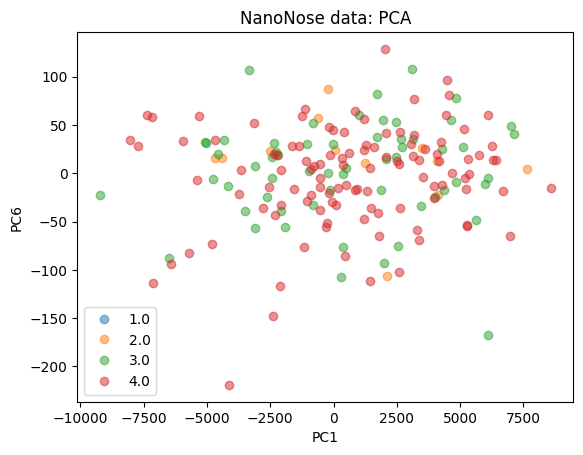

In [8]:
from matplotlib.pyplot import figure, legend, plot, show, title, xlabel, ylabel
from scipy.linalg import svd

# Subtract mean value from data
Y = X - np.ones((N, 1)) * X.mean(0)

# PCA by computing SVD of Y
U, S, Vh = svd(Y, full_matrices=False)
# scipy.linalg.svd returns "Vh", which is the Hermitian (transpose)
# of the vector V. So, for us to obtain the correct V, we transpose:
V = Vh.T

# Project the centered data onto principal component space
Z = Y @ V

# Indices of the principal components to be plotted
i = 0
j = 5

# Plot PCA of the data
f = figure()
title("NanoNose data: PCA")
# Z = array(Z)
for c in range(C):
    # select indices belonging to class c:
    class_mask = y == c
    plot(Z[class_mask, i], Z[class_mask, j], "o", alpha=0.5)

legend(classLabels)
xlabel("PC{0}".format(i + 1))
ylabel("PC{0}".format(j + 1))

# Output result to screen
show()

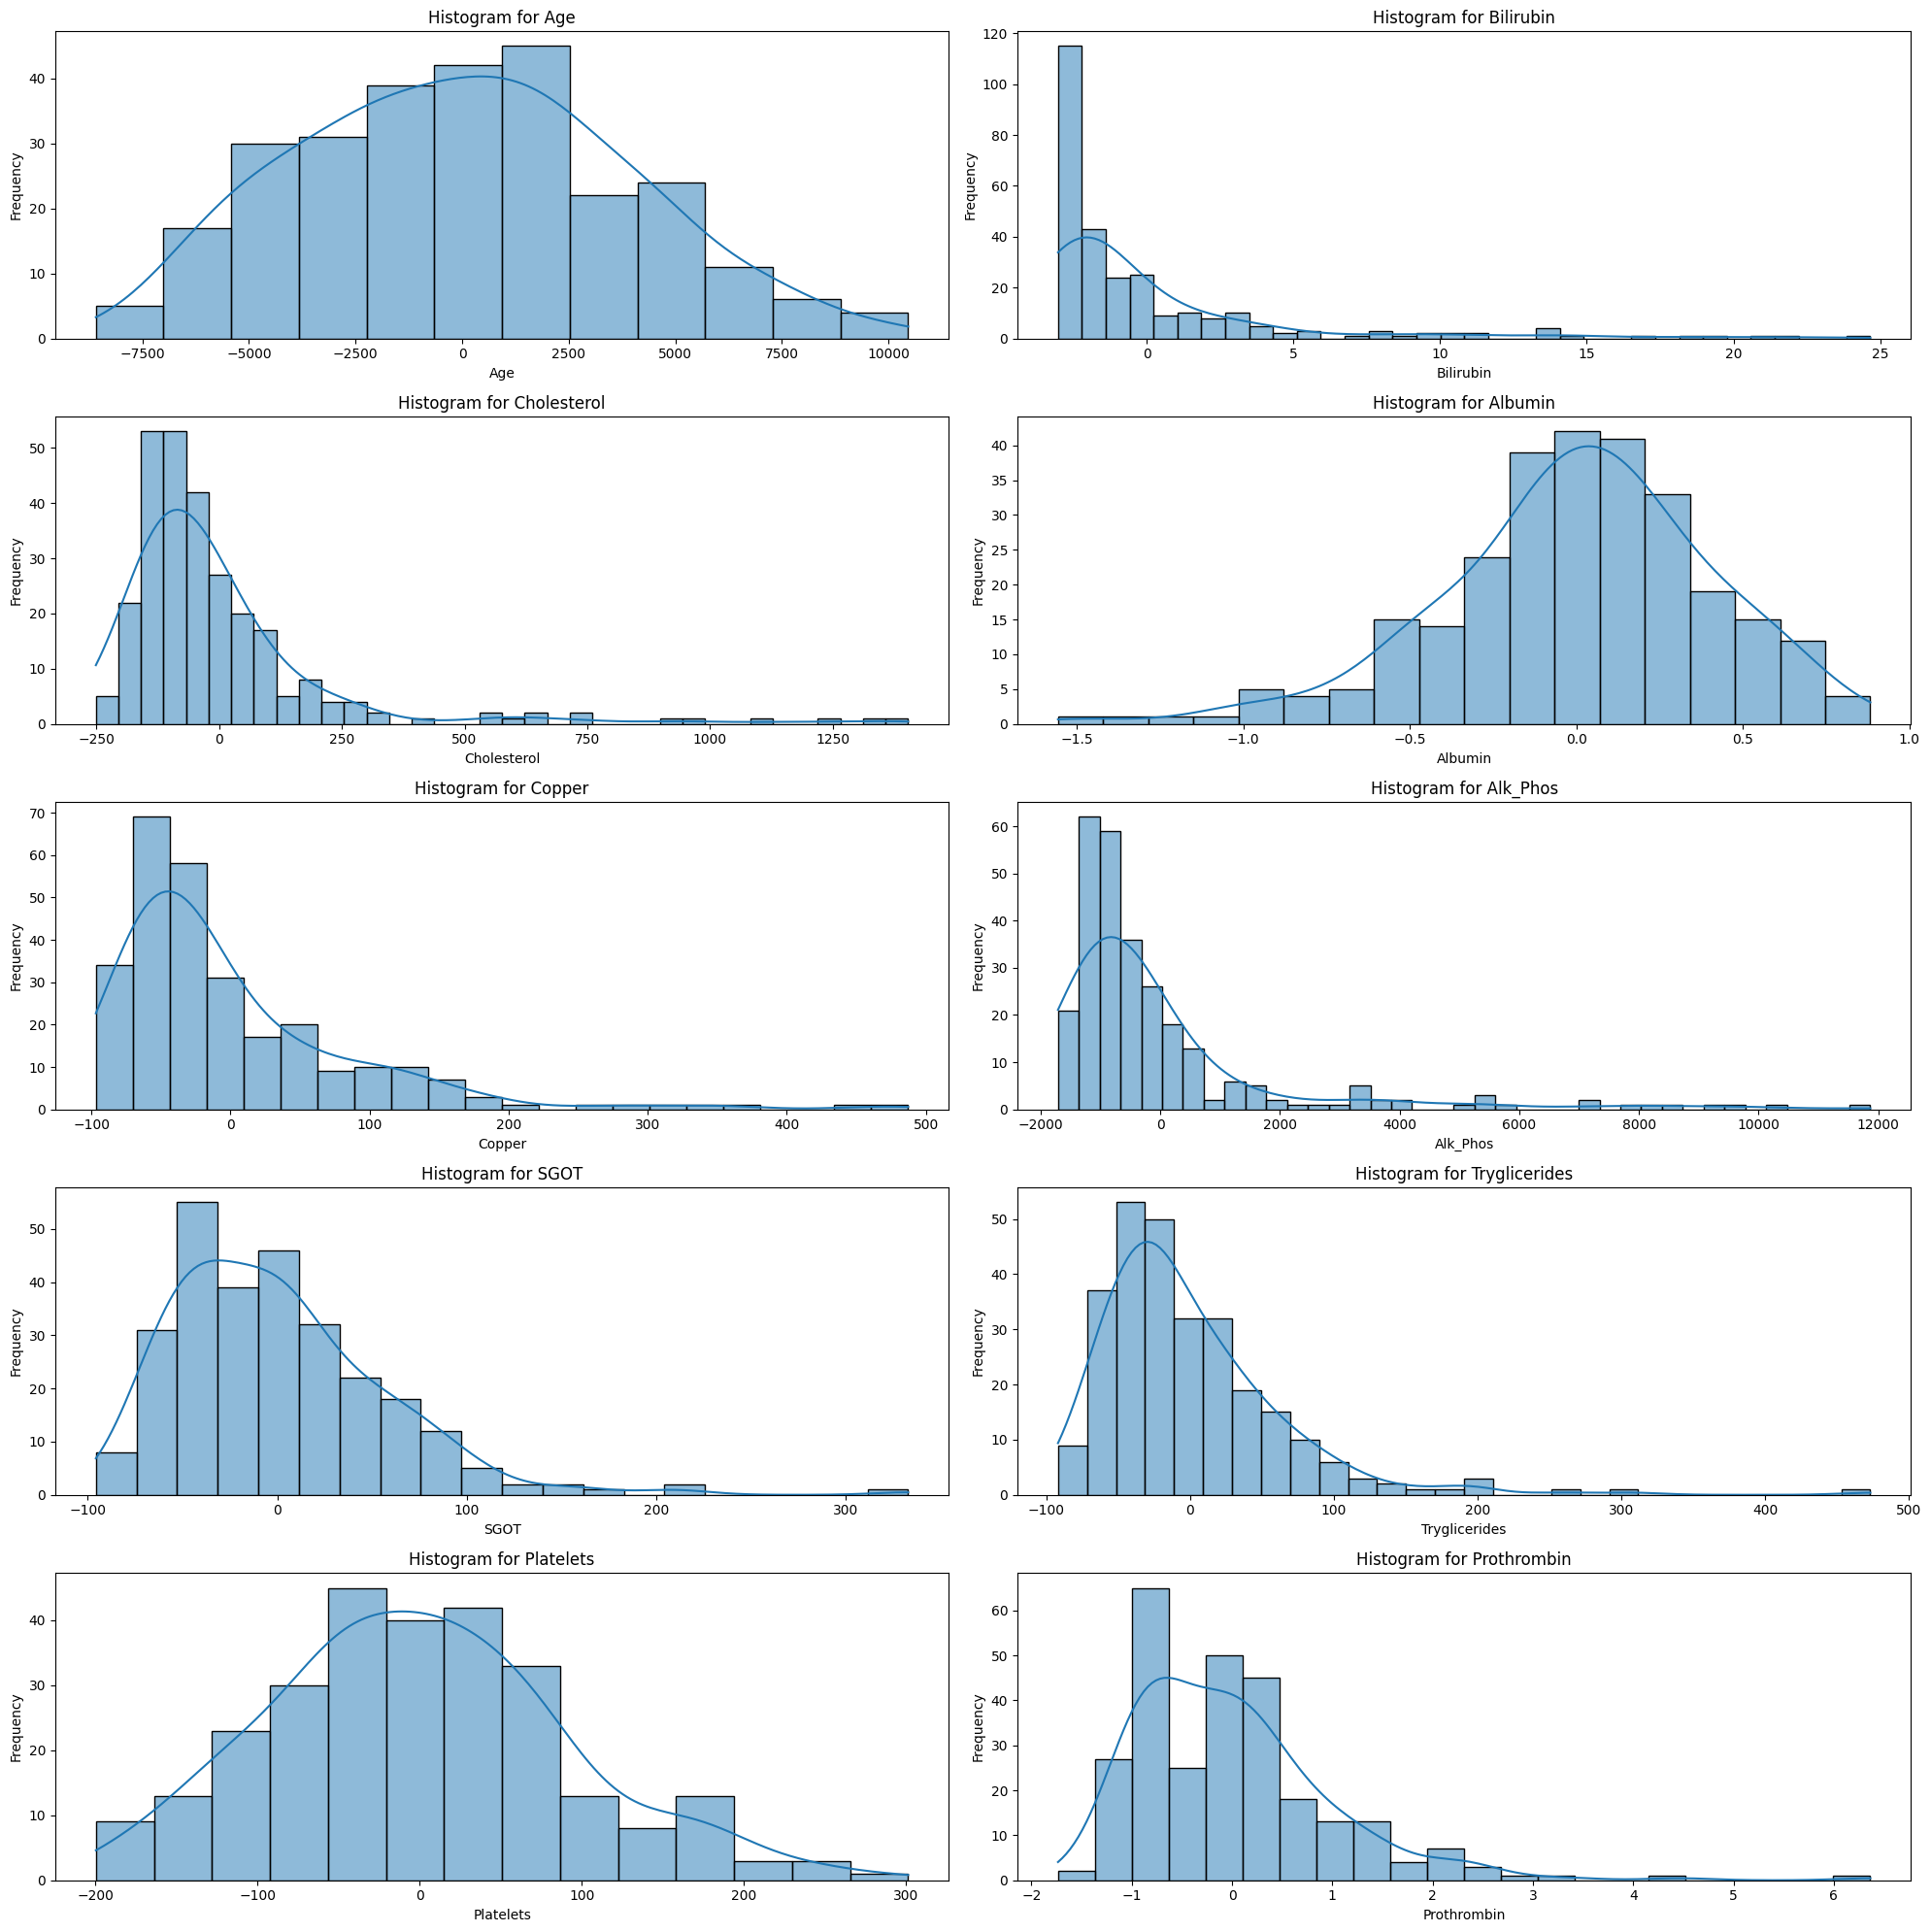

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a 4x4 grid of subplots
fig, axes = plt.subplots(5, 2, figsize=(20, 20))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Iterate over each column in X
for i, col_name in enumerate(attributeNames[:-1]):
    # Plot continuous line for the distribution
    sns.histplot(Y[:, i], ax=axes[i], kde=True)
    
    # Set title and labels
    axes[i].set_title(f'Histogram for {col_name}')
    axes[i].set_xlabel(col_name)
    axes[i].set_ylabel('Frequency')

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

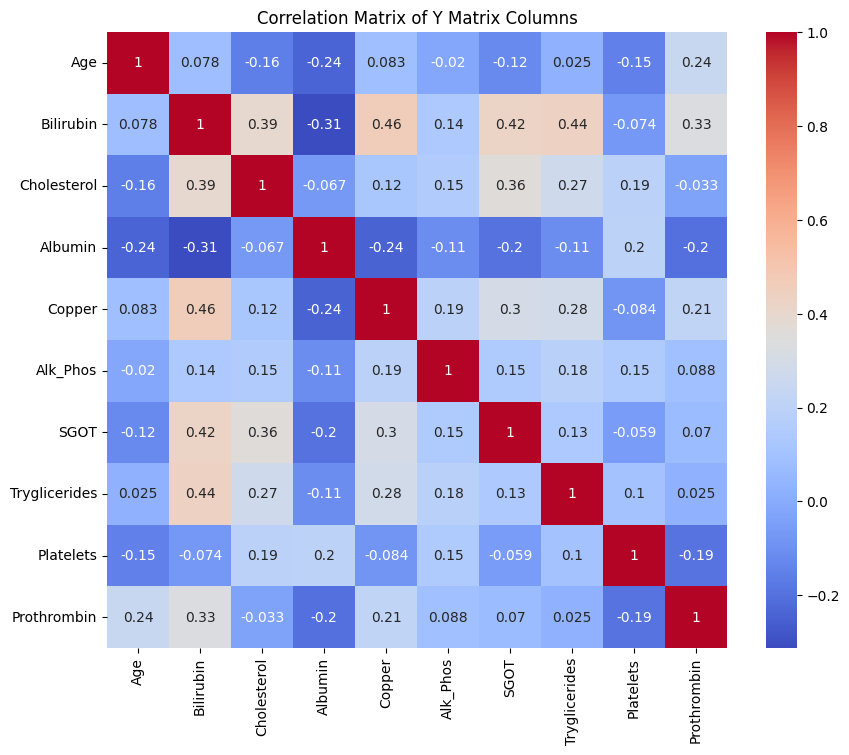

In [10]:
import seaborn as sns

import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = np.corrcoef(Y.T)

# Create a heatmap to visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', xticklabels=attributeNames[:-1], yticklabels=attributeNames[:-1])
plt.title('Correlation Matrix of Y Matrix Columns')
plt.show()

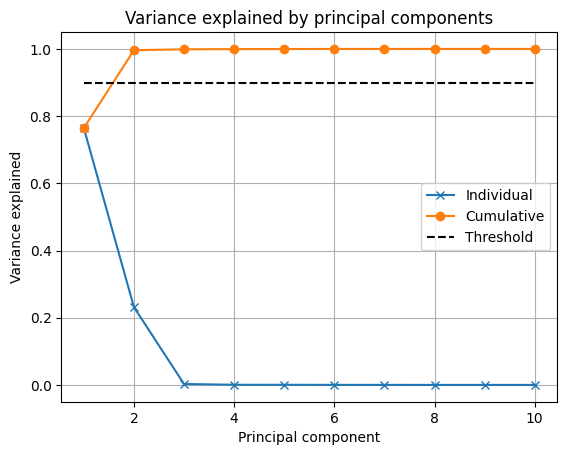

In [11]:
# Compute variance explained by principal components
rho = (S * S) / (S * S).sum()

threshold = 0.9

# Plot variance explained
plt.figure()
plt.plot(range(1, len(rho) + 1), rho, "x-")
plt.plot(range(1, len(rho) + 1), np.cumsum(rho), "o-")
plt.plot([1, len(rho)], [threshold, threshold], "k--")
plt.title("Variance explained by principal components")
plt.xlabel("Principal component")
plt.ylabel("Variance explained")
plt.legend(["Individual", "Cumulative", "Threshold"])
plt.grid()
plt.show()

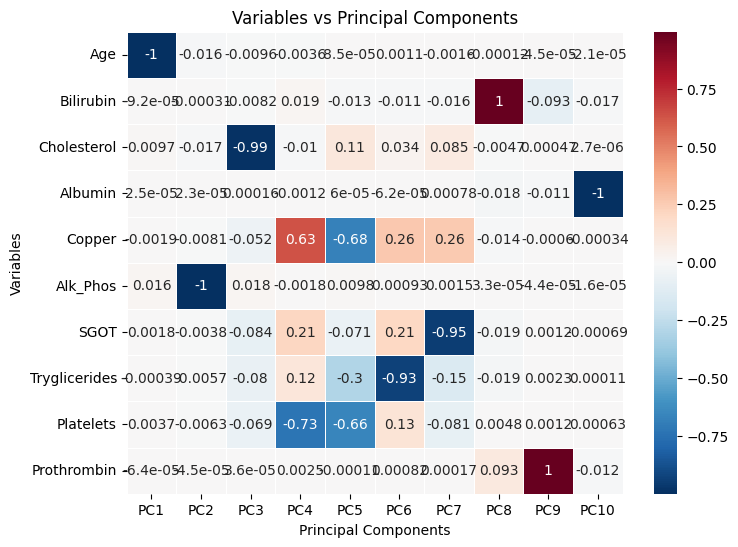

In [12]:


# Convert to DataFrame for easier handling
loading_df = pd.DataFrame(V, index=data.columns[:-1], columns=[f'PC{i+1}' for i in range(Vh.shape[0])])

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(V, annot=True, cmap='RdBu_r', center=0, linewidths=0.5, xticklabels=loading_df.columns, yticklabels=loading_df.index)



# Add labels and title
plt.title('Variables vs Principal Components')
plt.xlabel('Principal Components')
plt.ylabel('Variables')

# Display the plot
plt.show()

In [13]:
#import StandardScaler
from sklearn.preprocessing import StandardScaler

convert = ['Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Prothrombin', 'Cholesterol', 'Bilirubin']

# Convert the columns to log scale
for col in convert:
    data[col] = np.log(data[col])

# Preallocate memory, then extract excel data to matrix X
X = np.empty((len(data), 10))
for i, col_id in enumerate(range(0,10)):
    X[:, i] = np.asarray(data.iloc[:, col_id])

# Subtract mean value from data
Y = X - np.ones((N, 1)) * X.mean(0)

# scale the data in the range of [0, 1]
from sklearn.preprocessing import MinMaxScaler

scaler = StandardScaler()
Y_scaled = scaler.fit_transform(Y)

# PCA by computing SVD of Y
U, S, Vh = svd(Y_scaled, full_matrices=False)
# scipy.linalg.svd returns "Vh", which is the Hermitian (transpose)
# of the vector V. So, for us to obtain the correct V, we transpose:
V = Vh.T

# Project the centered data onto principal component space
Z = Y_scaled @ V

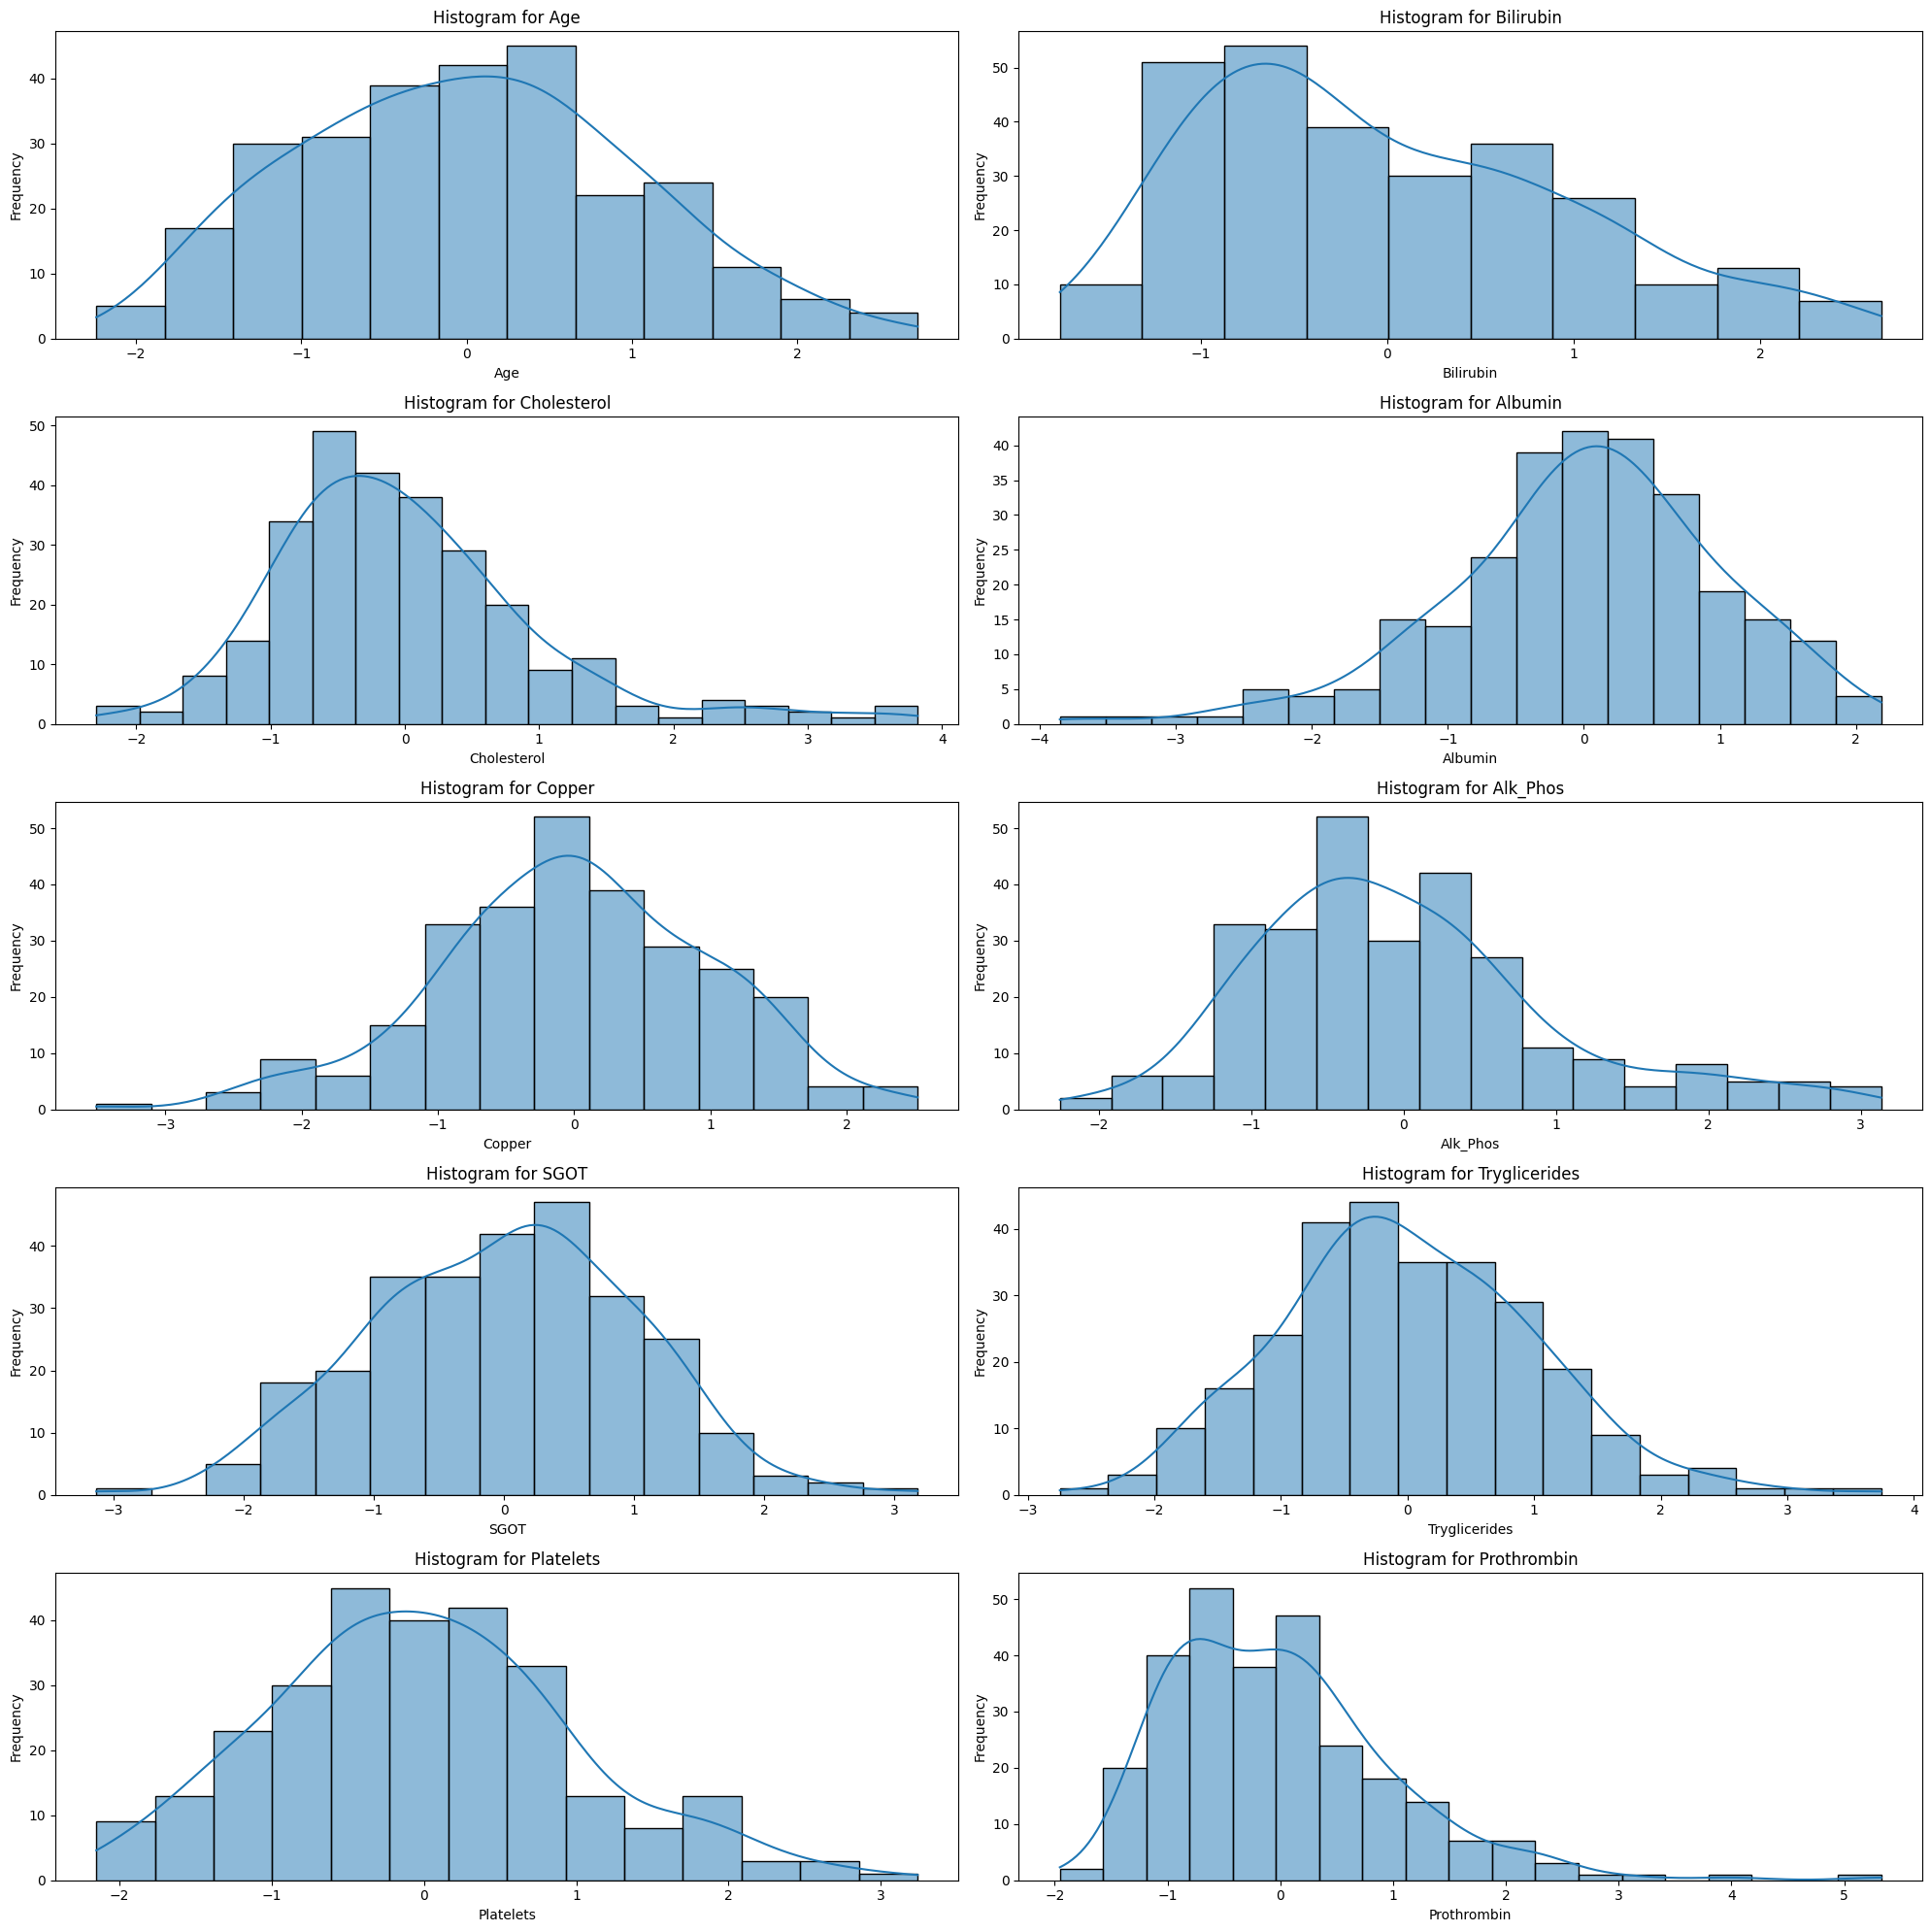

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns



# Create a 4x4 grid of subplots
fig, axes = plt.subplots(5, 2, figsize=(20, 20))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Iterate over each column in X
for i, col_name in enumerate(attributeNames[:-1]):
    # Plot continuous line for the distribution
    sns.histplot(Y_scaled[:, i], ax=axes[i], kde=True)
    
    # Set title and labels
    axes[i].set_title(f'Histogram for {col_name}')
    axes[i].set_xlabel(col_name)
    axes[i].set_ylabel('Frequency')

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

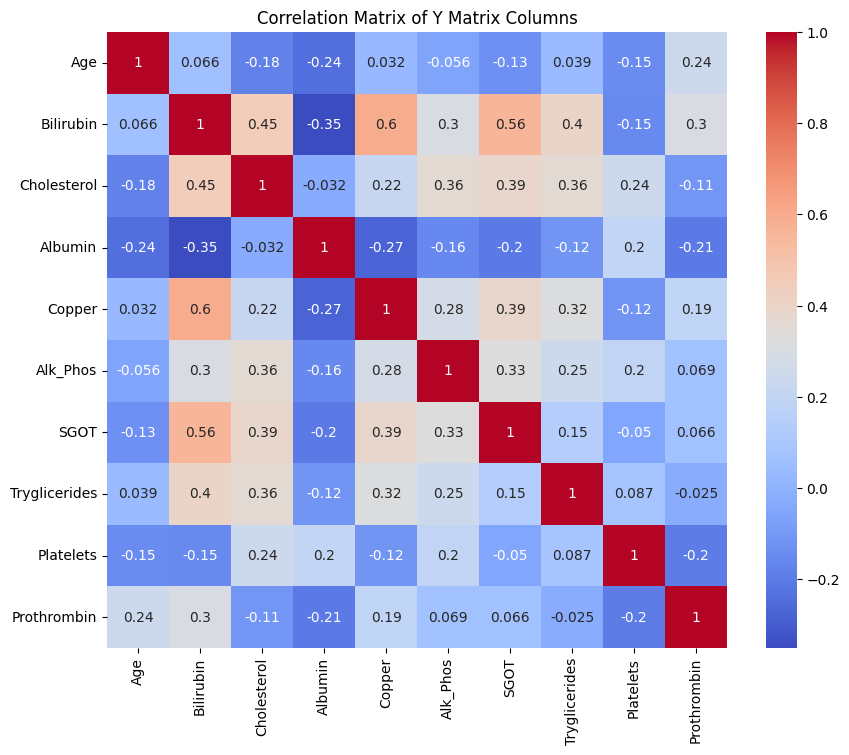

In [15]:
import seaborn as sns

import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = np.corrcoef(Y_scaled.T)

# Create a heatmap to visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', xticklabels=attributeNames[:-1], yticklabels=attributeNames[:-1])
plt.title('Correlation Matrix of Y Matrix Columns')
plt.show()

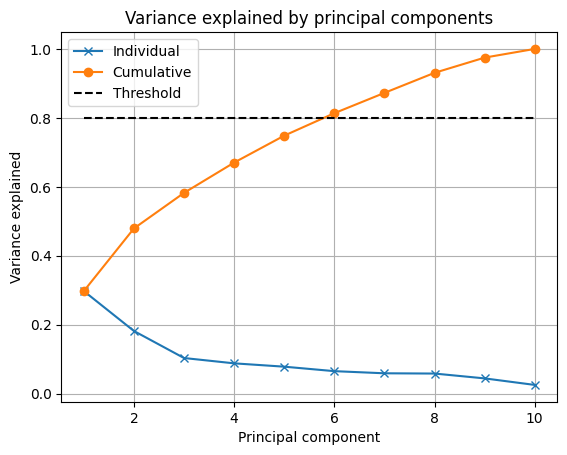

In [18]:
# Compute variance explained by principal components
rho = (S * S) / (S * S).sum()

threshold = 0.8

# Plot variance explained
plt.figure()
plt.plot(range(1, len(rho) + 1), rho, "x-")
plt.plot(range(1, len(rho) + 1), np.cumsum(rho), "o-")
plt.plot([1, len(rho)], [threshold, threshold], "k--")
plt.title("Variance explained by principal components")
plt.xlabel("Principal component")
plt.ylabel("Variance explained")
plt.legend(["Individual", "Cumulative", "Threshold"])
plt.grid()
plt.show()

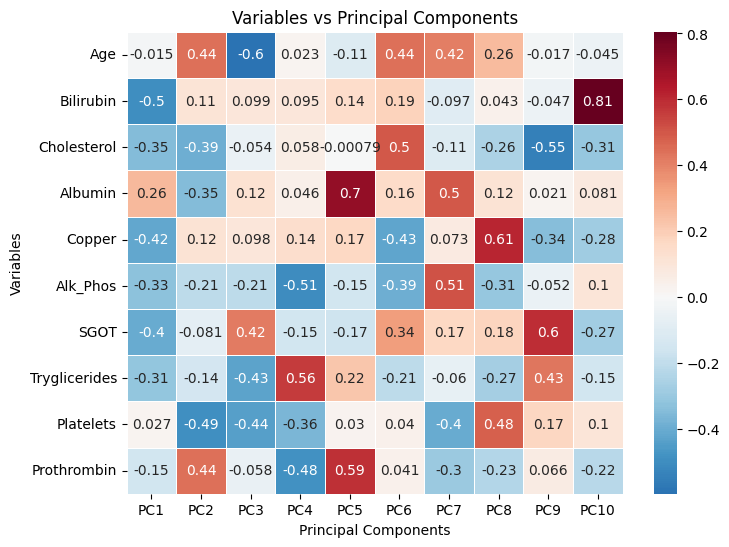

In [17]:


# Convert to DataFrame for easier handling
loading_df = pd.DataFrame(V, index=data.columns[:-1], columns=[f'PC{i+1}' for i in range(Vh.shape[0])])

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(V, annot=True, cmap='RdBu_r', center=0, linewidths=0.5, xticklabels=loading_df.columns, yticklabels=loading_df.index)



# Add labels and title
plt.title('Variables vs Principal Components')
plt.xlabel('Principal Components')
plt.ylabel('Variables')

# Display the plot
plt.show()

In [37]:
data

,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,2.674149,5.564520,2.60,5.049856,7.448916,4.926891,5.147494,190,2.501436,4.0
1,0.095310,5.710427,4.14,3.988984,8.908532,4.731979,4.477337,221,2.360854,3.0
2,0.336472,5.170484,3.48,5.347108,6.246107,4.565389,4.007333,151,2.484907,4.0
3,0.587787,5.497168,2.54,4.158883,8.719611,4.104790,4.521789,183,2.332144,4.0
4,1.223775,5.631212,3.53,4.962845,6.508769,4.728714,4.276666,136,2.388763,3.0
...,...,...,...,...,...,...,...,...,...,...
307,-0.916291,5.505332,3.58,3.178054,6.680855,4.510860,4.727388,288,2.341806,2.0
308,-0.916291,5.560682,2.75,3.713572,7.061334,4.248495,4.406719,231,2.379546,2.0
309,0.530628,6.073045,3.35,3.663562,7.446001,5.141664,4.605170,234,2.322388,2.0
310,0.693147,5.509388,3.16,4.234107,6.956545,4.762174,4.477337,335,2.351375,2.0


In [50]:
data.drop(['Age', 'Platelets'], axis=1, inplace=True)

# Preallocate memory, then extract excel data to matrix X
X = np.empty((len(data), 8))
for i, col_id in enumerate(range(0,8)):
    X[:, i] = np.asarray(data.iloc[:, col_id])

# Subtract mean value from data
Y = X - np.ones((N, 1)) * X.mean(0)

# PCA by computing SVD of Y
U, S, Vh = svd(Y, full_matrices=False)
# scipy.linalg.svd returns "Vh", which is the Hermitian (transpose)
# of the vector V. So, for us to obtain the correct V, we transpose:
V = Vh.T

# Project the centered data onto principal component space
Z = Y @ V

In [51]:
data.columns


Index(['Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT',
       'Tryglicerides', 'Prothrombin', 'Stage'],
      dtype='object')

In [52]:
# Subtract mean value from data
Y = X - np.ones((N, 1)) * X.mean(0)

# PCA by computing SVD of Y
U, S, Vh = svd(Y, full_matrices=False)
# scipy.linalg.svd returns "Vh", which is the Hermitian (transpose)
# of the vector V. So, for us to obtain the correct V, we transpose:
V = Vh.T

# Project the centered data onto principal component space
Z = Y @ V

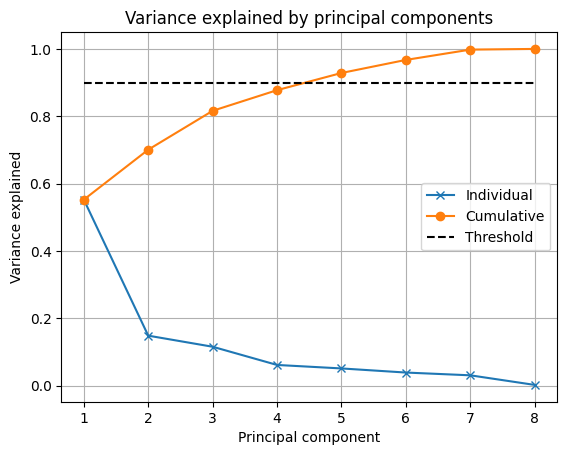

In [53]:
# Compute variance explained by principal components
rho = (S * S) / (S * S).sum()
# 
threshold = 0.9

# Plot variance explained
plt.figure()
plt.plot(range(1, len(rho) + 1), rho, "x-")
plt.plot(range(1, len(rho) + 1), np.cumsum(rho), "o-")
plt.plot([1, len(rho)], [threshold, threshold], "k--")
plt.title("Variance explained by principal components")
plt.xlabel("Principal component")
plt.ylabel("Variance explained")
plt.legend(["Individual", "Cumulative", "Threshold"])
plt.grid()
plt.show()

In [39]:
data.columns[:-1]

Index(['Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT',
       'Tryglicerides', 'Platelets', 'Prothrombin'],
      dtype='object')

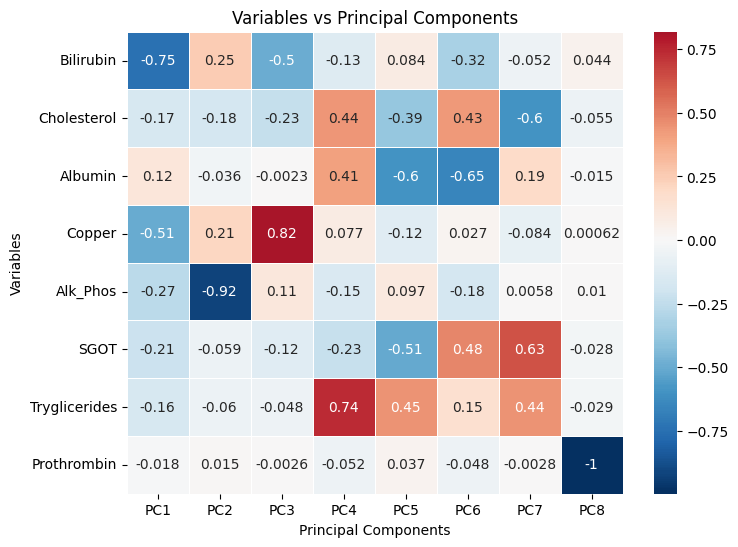

In [54]:


# Convert to DataFrame for easier handling
loading_df = pd.DataFrame(V, index=data.columns[:-1], columns=[f'PC{i+1}' for i in range(Vh.shape[0])])

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(V, annot=True, cmap='RdBu_r', center=0, linewidths=0.5, xticklabels=loading_df.columns, yticklabels=loading_df.index)



# Add labels and title
plt.title('Variables vs Principal Components')
plt.xlabel('Principal Components')
plt.ylabel('Variables')

# Display the plot
plt.show()